<a href="https://colab.research.google.com/github/Bauk006/uas-bigdata-reddit-data-sience-post-kelompok2/blob/main/Kode_Implementasi_Algoritma_Big_Data_Kelompok2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import LatentDirichletAllocation

!pip install pyLDAvis gensim

import gensim
from gensim.models import CoherenceModel
from gensim.corpora.dictionary import Dictionary
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

## **Load Data**

In [ ]:
# Load dataset
print("Memuat dataset hasil cleaning...")
df = pd.read_csv("reddit_data_science_posts_cleaned.csv", engine='python', on_bad_lines='skip')

# Hapus baris yang teks bersihnya kosong (NaN) agar model tidak error
df = df.dropna(subset=['clean_text', 'score', 'num_comments'])

df = df[df['clean_text'].str.strip() != '']

# Reset index agar urutan data kembali rapi
df = df.reset_index(drop=True)

if 'post_length' in df.columns:
    df['post_length'] = df['post_length'].fillna(0)

print(f"Dataset siap digunakan. Jumlah baris: {len(df)}")

Memuat dataset hasil cleaning...
Dataset siap digunakan. Jumlah baris: 54458


## **Topic Modeling (LDA) pada Kelas High Engagement**

In [ ]:
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import warnings

warnings.filterwarnings("ignore")

# Membuat metrik engagement
df['engagement'] = df['score'] + df['num_comments']

# Membuat kategori engagement
def set_engagement_category(x):
    if x >= 200:
        return 'High'
    elif x >= 50:
        return 'Medium'
    else:
        return 'Low'

df['engagement_category'] = df['engagement'].apply(set_engagement_category)

# Filter data High Engagement
df_high = df[df['engagement_category'] == 'High'].copy()
print(f"Jumlah data High Engagement yang dianalisis: {len(df_high)}\n")

# Persiapan corpus LDA
texts = [str(text).split() for text in df_high['clean_text']]
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Membuat model LDA
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=15
)

# Menampilkan topik
print("=== KATA KUNCI PER TOPIK (LDA) ===")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topik {idx+1}: {topic}")

# Evaluasi model
print("\n=== HASIL EVALUASI MODEL LDA ===")
perplexity_score = lda_model.log_perplexity(corpus)
print(f"Nilai Perplexity: {perplexity_score:.4f}")

coherence_model = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"Nilai Topic Coherence Score: {coherence_score:.4f}")

Jumlah data High Engagement yang dianalisis: 61

=== KATA KUNCI PER TOPIK (LDA) ===
Topik 1: 0.028*"data" + 0.021*"problem" + 0.014*"scienc" + 0.014*"learn" + 0.007*"tech" + 0.006*"would" + 0.006*"use" + 0.006*"engin" + 0.006*"im" + 0.006*"peopl"
Topik 2: 0.032*"data" + 0.015*"scientist" + 0.012*"know" + 0.012*"meter" + 0.011*"one" + 0.010*"say" + 0.009*"experi" + 0.008*"use" + 0.008*"scienc" + 0.008*"must"
Topik 3: 0.017*"data" + 0.012*"know" + 0.012*"im" + 0.010*"dont" + 0.009*"learn" + 0.009*"work" + 0.008*"use" + 0.008*"like" + 0.008*"new" + 0.008*"ive"
Topik 4: 0.035*"data" + 0.014*"ampnbsp" + 0.013*"need" + 0.012*"get" + 0.010*"scienc" + 0.009*"like" + 0.008*"scientist" + 0.008*"work" + 0.008*"make" + 0.008*"peopl"
Topik 5: 0.043*"data" + 0.015*"python" + 0.012*"scienc" + 0.011*"list" + 0.007*"learn" + 0.007*"podcast" + 0.007*"r" + 0.005*"machin" + 0.005*"program" + 0.005*"excel"

=== HASIL EVALUASI MODEL LDA ===
Nilai Perplexity: -6.9710
Nilai Topic Coherence Score: 0.3122


## **Intertopic Distance Map**

In [ ]:
# Visualisasi hasil LDA
pyLDAvis.enable_notebook()

vis = gensimvis.prepare(lda_model, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.067009 -0.054705       1        1  34.019897
1      0.072576  0.105506       2        1  25.056867
0     -0.125236  0.028604       3        1  18.352284
2      0.008801 -0.070343       4        1  17.340506
4     -0.023150 -0.009062       5        1   5.230446, topic_info=           Term        Freq       Total Category  logprob  loglift
18         data  157.000000  157.000000  Default  30.0000  30.0000
355     problem   33.000000   33.000000  Default  29.0000  29.0000
360      python   14.000000   14.000000  Default  28.0000  28.0000
1408      meter   16.000000   16.000000  Default  27.0000  27.0000
90      ampnbsp   27.000000   27.000000  Default  26.0000  26.0000
...         ...         ...         ...      ...      ...      ...
44          one    1.032108   30.309188   Topic5  -5.5782  -0.4292
465         use    1.032066   32.449849   Topic5  -5.5782  -0.4975
403         set    1.029873   13.948221   Topic5  -5.5803   0.3448
168        deal    1.029233   11.837841   Topic5  -5.5810   0.5082
397   scientist    1.027677   42.266921   Topic5  -5.5825  -0.7660

[352 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
1110      3  0.669493  accompani
82        1  0.968091        add
1273      5  0.838283   advantag
680       5  0.838132  adversari
1355      2  0.839247     aggreg
...     ...       ...        ...
69        4  0.054480      would
70        1  0.856869          x
71        1  0.381363       year
71        2  0.476703       year
71        3  0.190681       year

[559 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 1, 3, 5])

## **Word Cloud per Topik**

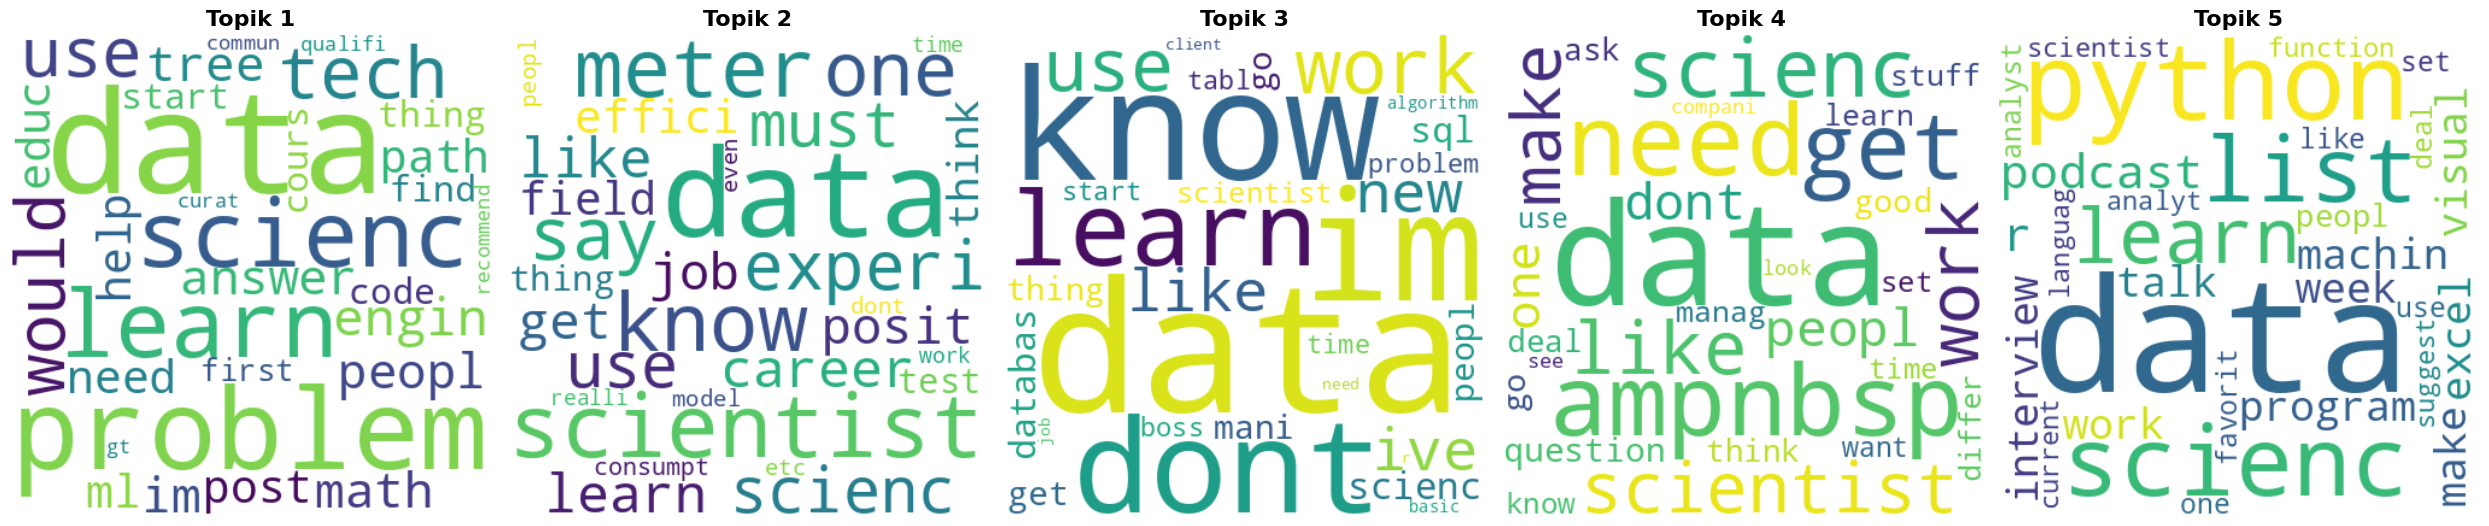

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Membuat visualisasi Word Cloud tiap topik
fig, axes = plt.subplots(1, 5, figsize=(25, 6), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)

    # Ambil kata kunci topik
    topic_words = dict(lda_model.show_topic(i, topn=30))

    # Generate Word Cloud
    cloud = WordCloud(
        background_color='white',
        width=400,
        height=400,
        colormap='viridis'
    ).generate_from_frequencies(topic_words)

    plt.gca().imshow(cloud, interpolation='bilinear')
    plt.gca().set_title(f'Topik {i+1}', fontdict=dict(size=16, weight='bold'))
    plt.gca().axis('off')

plt.tight_layout()
plt.show()

## **Analisis Prediktif (Random Forest)**

In [ ]:
import scipy.sparse as sp

# Membuat fitur post_length
if 'post_length' not in df.columns:
    df['post_length'] = df['title'].astype(str).apply(len)

# Ekstraksi fitur TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
X_text = tfidf.fit_transform(df['clean_text'].astype(str))

# Gabungkan fitur teks dan numerik
post_length_array = df['post_length'].values.reshape(-1, 1)
X_final = sp.hstack((X_text, post_length_array))

# Label target
y = df['engagement_category']

# Split data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

# Latih model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=2)
rf_model.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred = rf_model.predict(X_test)
print("=== CLASSIFICATION REPORT RANDOM FOREST ===")
print(classification_report(y_test, y_pred))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100building tree 2 of 100

building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   16.6s


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   45.4s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.4s finished


=== CLASSIFICATION REPORT RANDOM FOREST ===
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         8
         Low       0.98      1.00      0.99     10665
      Medium       0.12      0.02      0.03       219

    accuracy                           0.98     10892
   macro avg       0.37      0.34      0.34     10892
weighted avg       0.96      0.98      0.97     10892

